# PCBVision / PCBDataset preprocessing for gold-region masking

This notebook loads the PCBVision/PCBDataset data, performs lightweight preprocessing, and prepares feature tensors and **candidate** masks that can be refined later into gold-region masks.

In [7]:
from pathlib import Path
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
try:
    from scipy.signal import savgol_filter
except Exception:
    savgol_filter = None

try:
    from spectral import envi
except Exception as e:
    raise ImportError("spectral is required to read HSI cubes. Install with `pip install spectral`.") from e

%matplotlib inline


In [8]:
def find_dataset_root(start: Path) -> Path:
    """Find PCBDataset/PCBDataset directory by walking up parents."""
    start = start.resolve()
    for p in [start] + list(start.parents):
        candidate = p / 'PCBDataset' / 'PCBDataset'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find PCBDataset/PCBDataset from current working directory.')

PROJECT_ROOT = Path.cwd().resolve()
DATASET_ROOT = find_dataset_root(PROJECT_ROOT)
HSI_ROOT = DATASET_ROOT / 'HSI'
RGB_ROOT = DATASET_ROOT / 'RGB'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_ROOT:', DATASET_ROOT)
print('HSI_ROOT:', HSI_ROOT)
print('RGB_ROOT:', RGB_ROOT)


PROJECT_ROOT: C:\Users\mamma\OneDrive - University of Exeter\Documents\Computer Science\Year 3\Diss Project\HSIXRFDF
DATASET_ROOT: C:\Users\mamma\OneDrive - University of Exeter\Documents\Computer Science\Year 3\Diss Project\PCBDataset\PCBDataset
HSI_ROOT: C:\Users\mamma\OneDrive - University of Exeter\Documents\Computer Science\Year 3\Diss Project\PCBDataset\PCBDataset\HSI
RGB_ROOT: C:\Users\mamma\OneDrive - University of Exeter\Documents\Computer Science\Year 3\Diss Project\PCBDataset\PCBDataset\RGB


In [9]:
def list_sample_ids(hsi_root: Path):
    ids = []
    for p in hsi_root.glob('pcb*'):
        if p.is_dir() and p.name[3:].isdigit():
            ids.append(int(p.name[3:]))
    return sorted(ids)

sample_ids = list_sample_ids(HSI_ROOT)
len(sample_ids), sample_ids[:5]

(53, [1, 2, 3, 4, 5])

HSI shape (after drop): (572, 691, 214) dtype: float32
RGB shape: (1908, 2622, 3) dtype: uint8


(np.float64(-0.5), np.float64(2621.5), np.float64(1907.5), np.float64(-0.5))

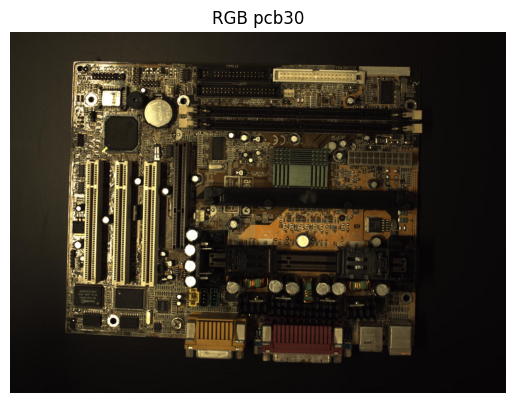

In [10]:
def read_hsi_cube(hsi_root: Path, pcb_id: int):
    pcb_dir = hsi_root / f'pcb{pcb_id}'
    hdr_path = pcb_dir / f'pcb{pcb_id}.hdr'
    raw_path = pcb_dir / f'pcb{pcb_id}'
    cube = envi.open(str(hdr_path), str(raw_path))
    return cube.open_memmap()

def read_rgb_image(rgb_root: Path, pcb_id: int):
    img_path = rgb_root / f'{pcb_id}.jpg'
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    return img
def read_wavelengths(hsi_root: Path, pcb_id: int) -> np.ndarray:
    """Read wavelength list from ENVI header metadata."""
    pcb_dir = hsi_root / f'pcb{pcb_id}'
    hdr_path = pcb_dir / f'pcb{pcb_id}.hdr'
    raw_path = pcb_dir / f'pcb{pcb_id}'
    cube = envi.open(str(hdr_path), str(raw_path))
    wl = cube.metadata.get('wavelength')
    if wl is None:
        return None
    return np.array([float(x) for x in wl], dtype=np.float32)

demo_id = int(np.random.choice(sample_ids))
hsi = read_hsi_cube(HSI_ROOT, demo_id)
wavelengths = read_wavelengths(HSI_ROOT, demo_id)
pcb_mask = read_pcb_mask(HSI_ROOT, demo_id, target_shape=hsi.shape[:2])
hsi, wavelengths = drop_noisy_bands(hsi, wavelengths, drop=10)
if pcb_mask is not None:
    pcb_mask = pcb_mask.astype(np.uint8)
rgb = read_rgb_image(RGB_ROOT, demo_id)

print('HSI shape (after drop):', hsi.shape, 'dtype:', hsi.dtype)
print('RGB shape:', rgb.shape, 'dtype:', rgb.dtype)
plt.imshow(rgb)
plt.title(f'RGB pcb{demo_id}')
plt.axis('off')


In [11]:
def normalize_hsi_cube(cube: np.ndarray, eps: float = 1e-6, pcb_mask: np.ndarray = None) -> np.ndarray:
    """Per-band min-max normalization to [0,1]. If pcb_mask is provided, stats are computed within the mask."""
    cube = cube.astype(np.float32)
    if pcb_mask is not None:
        mask = pcb_mask.astype(bool)
        if mask.sum() > 0:
            masked = cube[mask]
            band_min = masked.min(axis=0, keepdims=True)[None, None, :]
            band_max = masked.max(axis=0, keepdims=True)[None, None, :]
        else:
            band_min = cube.min(axis=(0, 1), keepdims=True)
            band_max = cube.max(axis=(0, 1), keepdims=True)
    else:
        band_min = cube.min(axis=(0, 1), keepdims=True)
        band_max = cube.max(axis=(0, 1), keepdims=True)
    return (cube - band_min) / (band_max - band_min + eps)

def select_bands(cube: np.ndarray, k: int = 10) -> np.ndarray:
    """Select k evenly spaced bands for lightweight features."""
    bands = cube.shape[2]
    idx = np.linspace(0, bands - 1, k).round().astype(int)
    return cube[:, :, idx]

def rgb_gold_candidate_mask(rgb: np.ndarray):
    """
    Heuristic RGB->HSV thresholding for gold-like regions.
    Tune thresholds later based on lab measurements.
    """
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    # Hue range ~15-50 for yellow/gold; S and V moderate/high
    lower = np.array([15, 40, 50])
    upper = np.array([50, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    # Clean small noise
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask

def rgb_feature_stack(rgb: np.ndarray) -> np.ndarray:
    """Create a compact feature stack from RGB, HSV, and LAB."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    # Stack channels: RGB(3) + HSV(3) + LAB(3) = 9
    feat = np.concatenate([rgb, hsv, lab], axis=2)
    return feat.astype(np.uint8)

def savgol_spectral_smooth(cube: np.ndarray, window_length: int = 11, polyorder: int = 2) -> np.ndarray:
    """Optional Savitzky-Golay smoothing along spectral axis."""
    if savgol_filter is None:
        raise ImportError('scipy is required for Savitzky-Golay smoothing.')
    return savgol_filter(cube, window_length=window_length, polyorder=polyorder, axis=2)

def median_filter_bands(cube: np.ndarray, band_indices, ksize: int = 3) -> np.ndarray:
    """Optional median filter on selected bands (spatial)."""
    out = cube.copy()
    for b in band_indices:
        out[:, :, b] = cv2.medianBlur(out[:, :, b].astype(np.float32), ksize)
    return out

def band_ratio_index(cube_norm: np.ndarray, wavelengths: np.ndarray, low_nm: float = 500.0, high_nm: float = 600.0, eps: float = 1e-6):
    """Simple band ratio index for a rise between low_nm and high_nm."""
    if wavelengths is None:
        return None
    i_low = int(np.argmin(np.abs(wavelengths - low_nm)))
    i_high = int(np.argmin(np.abs(wavelengths - high_nm)))
    low = cube_norm[:, :, i_low]
    high = cube_norm[:, :, i_high]
    return (high - low) / (high + low + eps)

def spectral_angle_map(cube_norm: np.ndarray, ref_spectrum: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Spectral angle mapper (SAM). Lower = more similar."""
    ref = ref_spectrum.astype(np.float32)
    ref = ref / (np.linalg.norm(ref) + eps)
    flat = cube_norm.reshape(-1, cube_norm.shape[2])
    flat = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + eps)
    cosang = np.clip((flat * ref).sum(axis=1), -1.0, 1.0)
    ang = np.arccos(cosang).reshape(cube_norm.shape[0], cube_norm.shape[1])
    return ang

def pca_features(cube_norm: np.ndarray, n_components: int = 10, pcb_mask: np.ndarray = None) -> np.ndarray:
    """PCA features over spectra. Fits on masked pixels if pcb_mask provided."""
    h, w, b = cube_norm.shape
    flat = cube_norm.reshape(-1, b)
    if pcb_mask is not None:
        mask = pcb_mask.astype(bool).reshape(-1)
        fit_data = flat[mask]
    else:
        fit_data = flat
    pca = PCA(n_components=n_components, random_state=0)
    pca.fit(fit_data)
    proj = pca.transform(flat).reshape(h, w, n_components)
    return proj

def clean_mask(mask: np.ndarray, min_area: int = 100) -> np.ndarray:
    """Remove small connected components from a binary mask."""
    num, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, num):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 255
    return out

def _band_index_from_percentile(cube: np.ndarray, pct: float) -> int:
    """Pick a band index by percentile when wavelengths are unknown."""
    bands = cube.shape[2]
    idx = int(round((bands - 1) * pct))
    return max(0, min(bands - 1, idx))

def read_pcb_mask(hsi_root: Path, pcb_id: int, target_shape=None) -> np.ndarray:
    """Read PCB mask (grayscale) and optionally resize to target_shape (H, W)."""
    mask_path = hsi_root / 'PCB_Masks' / f'{pcb_id}.jpg'
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    if target_shape is not None and (mask.shape[0] != target_shape[0] or mask.shape[1] != target_shape[1]):
        mask = cv2.resize(mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
    # Convert to boolean mask
    return (mask > 0).astype(np.uint8)

def drop_noisy_bands(cube: np.ndarray, wavelengths: np.ndarray = None, drop: int = 10):
    """Drop the first `drop` spectral bands (often noisy)."""
    if drop <= 0:
        return cube, wavelengths
    cube_out = cube[:, :, drop:]
    if wavelengths is None:
        return cube_out, None
    return cube_out, wavelengths[drop:]

def _closest_band_index(wavelengths: np.ndarray, target_nm: float) -> int:
    idx = int(np.argmin(np.abs(wavelengths - target_nm)))
    return idx

def hsi_gold_spectral_index(cube_norm: np.ndarray,
                            wavelengths: np.ndarray = None,
                            low_nm: float = 550.0,
                            mid_nm: float = 700.0,
                            high_nm: float = 900.0,
                            low_pct: float = 0.1,
                            mid_pct: float = 0.5,
                            high_pct: float = 0.8,
                            eps: float = 1e-6) -> np.ndarray:
    """
    Spectral heuristic index for gold-like reflectance.
    Uses explicit wavelengths when available, otherwise falls back to percentiles.
    """
    if wavelengths is not None and len(wavelengths) == cube_norm.shape[2]:
        b_low = _closest_band_index(wavelengths, low_nm)
        b_mid = _closest_band_index(wavelengths, mid_nm)
        b_high = _closest_band_index(wavelengths, high_nm)
    else:
        b_low = _band_index_from_percentile(cube_norm, low_pct)
        b_mid = _band_index_from_percentile(cube_norm, mid_pct)
        b_high = _band_index_from_percentile(cube_norm, high_pct)

    low = cube_norm[:, :, b_low]
    mid = cube_norm[:, :, b_mid]
    high = cube_norm[:, :, b_high]

    # Emphasize rise from low to high wavelengths and suppress flat spectra
    index = (high - low) / (high + low + eps)
    index = index - 0.5 * (mid - low) / (mid + low + eps)
    return index

def hsi_gold_candidate_mask(cube_norm: np.ndarray, wavelengths: np.ndarray = None, pcb_mask: np.ndarray = None) -> np.ndarray:
    """Otsu thresholding on a spectral index to find candidate gold regions."""
    idx = np.squeeze(hsi_gold_spectral_index(cube_norm, wavelengths=wavelengths))
    if idx.ndim != 2:
        raise ValueError(f"Expected 2D spectral index for thresholding, got shape {idx.shape}")
    idx_norm = idx - idx.min()
    idx_norm = idx_norm / (idx_norm.max() + 1e-6)
    idx_u8 = (idx_norm * 255).astype(np.uint8)
    _, mask = cv2.threshold(idx_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    if pcb_mask is not None:
        mask = mask * pcb_mask.astype(np.uint8)
    return mask

def hsi_kmeans_mask(cube_norm: np.ndarray,
                    pcb_mask: np.ndarray = None,
                    n_clusters: int = 5,
                    sample_stride: int = 4,
                    random_state: int = 0):
    """
    K-means clustering on spectra. Returns labels and cluster centers.
    sample_stride downsamples for speed.
    """
    h, w, b = cube_norm.shape
    sample_cube = cube_norm[::sample_stride, ::sample_stride, :]
    if pcb_mask is not None:
        mask_small = pcb_mask[::sample_stride, ::sample_stride]
        sample = sample_cube[mask_small > 0].reshape(-1, b)
    else:
        sample = sample_cube.reshape(-1, b)
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    km.fit(sample)

    labels = km.predict(cube_norm.reshape(-1, b)).reshape(h, w)
    if pcb_mask is not None:
        labels = labels * pcb_mask.astype(labels.dtype)
    centers = km.cluster_centers_
    return labels, centers

def select_cluster_by_slope(centers: np.ndarray, wavelengths: np.ndarray,
                            low_nm: float = 500.0, high_nm: float = 600.0) -> int:
    """
    Pick cluster with the steepest positive slope between low_nm and high_nm.
    Returns cluster index.
    """
    if wavelengths is None or len(wavelengths) != centers.shape[1]:
        return 0
    idx_low = int(np.argmin(np.abs(wavelengths - low_nm)))
    idx_high = int(np.argmin(np.abs(wavelengths - high_nm)))
    if idx_high == idx_low:
        return 0
    if idx_high < idx_low:
        idx_low, idx_high = idx_high, idx_low
    win = 2
    low_vals = centers[:, max(0, idx_low - win):min(centers.shape[1], idx_low + win + 1)].mean(axis=1)
    high_vals = centers[:, max(0, idx_high - win):min(centers.shape[1], idx_high + win + 1)].mean(axis=1)
    slopes = (high_vals - low_vals) / (wavelengths[idx_high] - wavelengths[idx_low])
    return int(np.argmax(slopes))


Feature stack shape: (1908, 2622, 9)


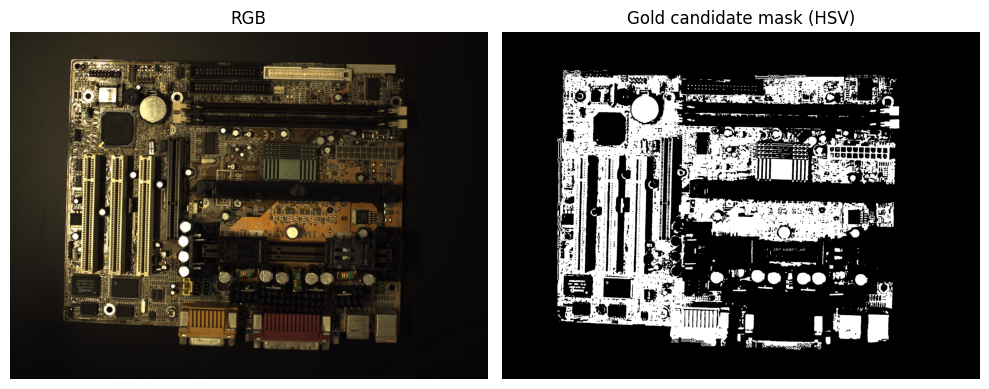

In [12]:
mask = rgb_gold_candidate_mask(rgb)
if pcb_mask is not None:
    # Resize PCB mask to RGB size if needed
    if pcb_mask.shape[0] != rgb.shape[0] or pcb_mask.shape[1] != rgb.shape[1]:
        pcb_mask_rgb = cv2.resize(pcb_mask, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        pcb_mask_rgb = pcb_mask
    mask = mask * pcb_mask_rgb.astype(np.uint8)
feat = rgb_feature_stack(rgb)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb)
ax[0].set_title('RGB')
ax[0].axis('off')
ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Gold candidate mask (HSV)')
ax[1].axis('off')
plt.tight_layout()

print('Feature stack shape:', feat.shape)

In [15]:
#Optional denoising (uncomment to apply)
hsi_smooth = savgol_spectral_smooth(hsi_norm, window_length=11, polyorder=2)
hsi_smooth = median_filter_bands(hsi_smooth, band_indices=[0, 10, 20], ksize=3)
#Use hsi_smooth in place of hsi_norm below if desired.


ValueError: too many values to unpack (expected 3)

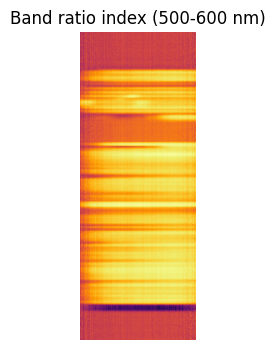

In [16]:
#Optional spectral features
ratio_idx = band_ratio_index(hsi_norm, wavelengths, low_nm=500.0, high_nm=600.0)
if ratio_idx is not None:
    ratio_idx = np.squeeze(ratio_idx)
    if ratio_idx.ndim != 2:
        raise ValueError(f"Band ratio index must be 2D for display, got {ratio_idx.shape}")
    plt.figure(figsize=(5, 4))
    plt.imshow(ratio_idx, cmap='inferno')
    plt.title('Band ratio index (500-600 nm)')
    plt.axis('off')
#Optional PCA features
pca_feats = pca_features(hsi_norm, n_components=10, pcb_mask=pcb_mask)
print('PCA feature shape:', pca_feats.shape)


In [17]:
hsi = read_hsi_cube(HSI_ROOT, demo_id)
wavelengths = read_wavelengths(HSI_ROOT, demo_id)
pcb_mask = read_pcb_mask(HSI_ROOT, demo_id, target_shape=hsi.shape[:2])
hsi, wavelengths = drop_noisy_bands(hsi, wavelengths, drop=10)
hsi_norm = normalize_hsi_cube(hsi, pcb_mask=pcb_mask)
hsi_index = np.squeeze(hsi_gold_spectral_index(hsi_norm, wavelengths=wavelengths))
if hsi_index.ndim != 2:
    raise ValueError(f"HSI spectral index must be 2D for display, got {hsi_index.shape}")
hsi_mask = hsi_gold_candidate_mask(hsi_norm, wavelengths=wavelengths, pcb_mask=pcb_mask)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(hsi_index, cmap='inferno')
ax[0].set_title('HSI spectral index')
ax[0].axis('off')
ax[1].imshow(hsi_mask, cmap='gray')
ax[1].set_title('Gold candidate mask (HSI)')
ax[1].axis('off')
plt.tight_layout()


ValueError: operands could not be broadcast together with shapes (572,214) (572,691) 

In [18]:
# K-means clustering on HSI spectra (no gold ROI required)
labels, centers = hsi_kmeans_mask(hsi_norm, pcb_mask=pcb_mask, n_clusters=5, sample_stride=4)

plt.figure(figsize=(5, 4))
plt.imshow(labels, cmap='tab20')
plt.title('HSI k-means cluster map')
plt.axis('off')

# Plot mean spectra per cluster for manual selection
plt.figure(figsize=(6, 4))
if 'wavelengths' in globals() and wavelengths is not None:
    if len(wavelengths) == centers.shape[1]:
        x_axis = wavelengths
    elif len(wavelengths) > centers.shape[1]:
        x_axis = wavelengths[:centers.shape[1]]
    else:
        x_axis = np.arange(centers.shape[1])
else:
    x_axis = np.arange(centers.shape[1])
for i, c in enumerate(centers):
    plt.plot(x_axis, c, label=f'cluster {i}')
plt.title('Cluster mean spectra')
plt.xlabel('Wavelength (nm)' if len(x_axis) == centers.shape[1] and x_axis is not None and x_axis.ndim == 1 else 'Band index')
plt.ylabel('Normalized reflectance')
plt.legend()
plt.tight_layout()

# Choose a cluster ID that looks gold-like (by spectrum/visual overlay)
# Auto-select cluster with sharpest rise between 500–600 nm (fallback to 0)
if 'wavelengths' in globals() and wavelengths is not None and len(wavelengths) == centers.shape[1]:
    gold_cluster_id = select_cluster_by_slope(centers, wavelengths, low_nm=500.0, high_nm=600.0)
else:
    gold_cluster_id = 0
print('Selected gold_cluster_id:', gold_cluster_id)
kmeans_gold_mask = (labels == gold_cluster_id).astype(np.uint8) * 255
if pcb_mask is not None:
    kmeans_gold_mask = kmeans_gold_mask * pcb_mask.astype(np.uint8)
kmeans_gold_mask = clean_mask(kmeans_gold_mask, min_area=100)

plt.figure(figsize=(5, 4))
plt.imshow(kmeans_gold_mask, cmap='gray')
plt.title(f'Gold candidate mask (k-means cluster {gold_cluster_id})')
plt.axis('off')

ValueError: too many values to unpack (expected 3)

In [19]:
# Batch preprocess and save lightweight outputs
# NOTE: This writes to HSIXRFDF/processed. Adjust as needed.
out_dir = PROJECT_ROOT / 'HSIXRFDF' / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

for pcb_id in sample_ids:
    rgb = read_rgb_image(RGB_ROOT, pcb_id)
    rgb_mask = rgb_gold_candidate_mask(rgb)
    if pcb_mask is not None:
        if pcb_mask.shape[0] != rgb.shape[0] or pcb_mask.shape[1] != rgb.shape[1]:
            pcb_mask_rgb = cv2.resize(pcb_mask, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            pcb_mask_rgb = pcb_mask
        rgb_mask = rgb_mask * pcb_mask_rgb.astype(np.uint8)
    rgb_feat = rgb_feature_stack(rgb)

    # Save RGB features and candidate mask
    np.save(out_dir / f'rgb_features_pcb{pcb_id}.npy', rgb_feat)
    Image.fromarray(rgb_mask).save(out_dir / f'gold_candidate_rgb_pcb{pcb_id}.png')

    # HSI: normalize and select a small set of bands to keep files small
    hsi = read_hsi_cube(HSI_ROOT, pcb_id)
    wavelengths = read_wavelengths(HSI_ROOT, pcb_id)
    pcb_mask = read_pcb_mask(HSI_ROOT, pcb_id, target_shape=hsi.shape[:2])
    hsi, wavelengths = drop_noisy_bands(hsi, wavelengths, drop=10)
    hsi_norm = normalize_hsi_cube(hsi, pcb_mask=pcb_mask)
    hsi_bands = select_bands(hsi_norm, k=10)
    np.save(out_dir / f'hsi_bands10_pcb{pcb_id}.npy', hsi_bands)
    hsi_mask = hsi_gold_candidate_mask(hsi_norm, wavelengths=wavelengths, pcb_mask=pcb_mask)
    Image.fromarray(hsi_mask).save(out_dir / f'gold_candidate_hsi_pcb{pcb_id}.png')

print('Saved preprocessing outputs to', out_dir)

ValueError: operands could not be broadcast together with shapes (272,214) (272,499) 

## Next steps
- Replace HSV thresholds with gold-specific calibration (e.g., lab-measured spectra).
- Train a classifier/segmentation model using the saved features.
- Use PCB masks or general masks from the dataset to filter background before thresholding.

In [ ]:
# Optional dataset-level utilities
# Train/val split by PCB id
# train_ids, val_ids = train_test_split(sample_ids, test_size=0.2, random_state=42)
# print('Train IDs:', train_ids) 
# print('Val IDs:', val_ids)

# Patch extraction (simple example)
# def extract_patches(image, mask, patch_size=64, stride=32):
#     patches = []
#     for y in range(0, image.shape[0] - patch_size + 1, stride):
#         for x in range(0, image.shape[1] - patch_size + 1, stride):
#             patch = image[y:y+patch_size, x:x+patch_size]
#             if mask is None or mask[y:y+patch_size, x:x+patch_size].mean() > 0:
#                 patches.append(patch)
#     return patches

# Normalization stats (save for reproducibility)
# def compute_band_stats(cube_norm, pcb_mask=None):
#     if pcb_mask is not None:
#         data = cube_norm[pcb_mask.astype(bool)]
#     else:
#         data = cube_norm.reshape(-1, cube_norm.shape[2])
#     return data.mean(axis=0), data.std(axis=0)
